# K-Nearest Neighbors - Diabetes Classification

This notebook implements the K-Nearest Neighbors (KNN) algorithm for the diabetes classification problem.


In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
np.random.seed(42)

In [2]:
# Load the dataset

df = pd.read_csv("../dataset/diabetes_prediction_dataset_2000.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [3]:
# Basic dataset checking

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4


In [4]:
# Removing duplicates

before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)

Rows before removing duplicates: 2000
Duplicate rows removed: 4
Rows after removing duplicates: 1996


In [5]:
# Checking missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values were found, so no imputation was required.")
else:
    numerical_missing = df.select_dtypes(include=np.number).columns
    categorical_missing = df.select_dtypes(exclude=np.number).columns

    for col in numerical_missing:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    for col in categorical_missing:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    print("Missing values were handled using median imputation for numerical columns and mode imputation for categorical columns.")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

No missing values were found, so no imputation was required.

Missing values after cleaning:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [6]:
# Checking diabetes classes

print("Diabetes counts:")
print(df["diabetes"].value_counts())

print("\nPercentage of each class:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


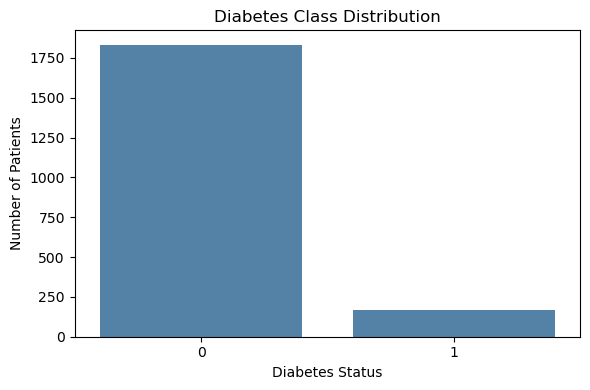

In [7]:
# Diabetes class distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diabetes", color="steelblue")
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insight

The target distribution shows how many patients belong to each diabetes class. The two classes are not equally represented, so the class distribution should be considered when interpreting classification metrics.

In [8]:
# Numerical features

num_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

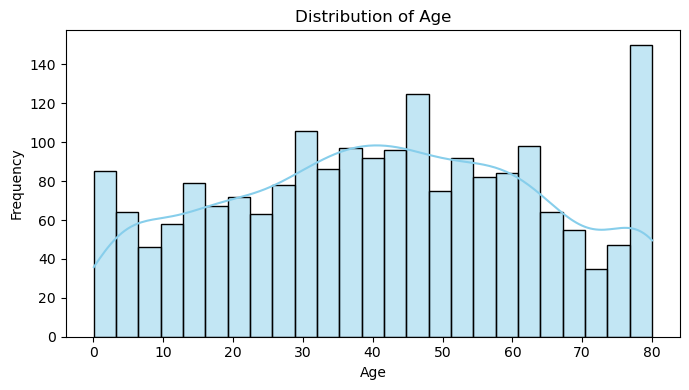

In [9]:
# Age distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=25, kde=True, color="skyblue")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The age distribution shows how the patients are spread across different age groups. It helps identify the main age range represented in the dataset and whether the distribution is concentrated or spread out.

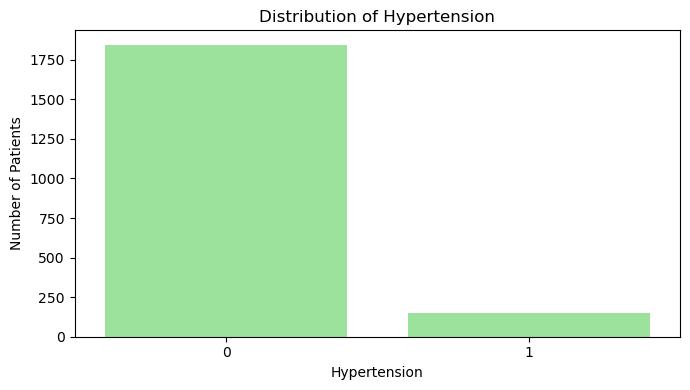

In [10]:
# Hypertension distribution

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="hypertension", color="lightgreen")
plt.title("Distribution of Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insight

Hypertension is a binary health indicator where 0 represents patients without hypertension and 1 represents patients with hypertension. A count plot is used because it clearly compares the frequency of the two categories. The plot shows that most patients have a value of 0, indicating that hypertension is an imbalanced feature in this dataset.

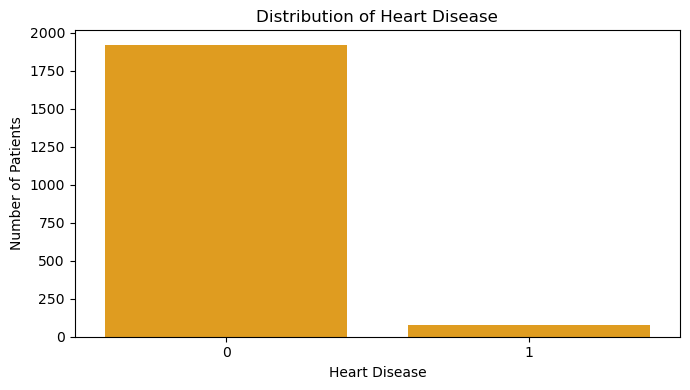

In [11]:
# Heart disease distribution

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="heart_disease", color="orange")
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insight

Heart disease is another binary health indicator. The count plot shows the number of patients in each category and helps identify whether the feature is balanced or dominated by one of the two values.

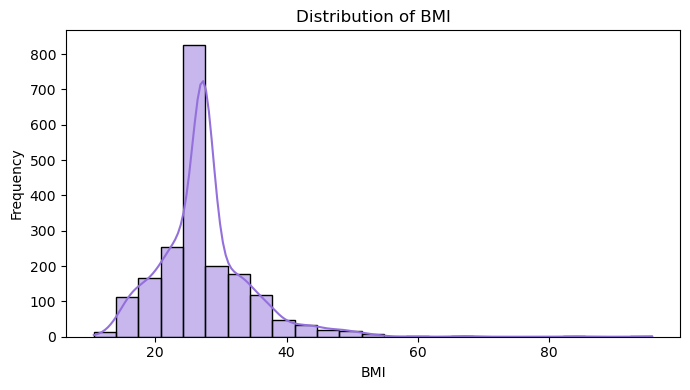

In [12]:
# BMI distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["bmi"], bins=25, kde=True, color="mediumpurple")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The BMI distribution shows the range and concentration of body-mass values among the patients. The plot also helps identify the overall shape and spread of this numerical feature.

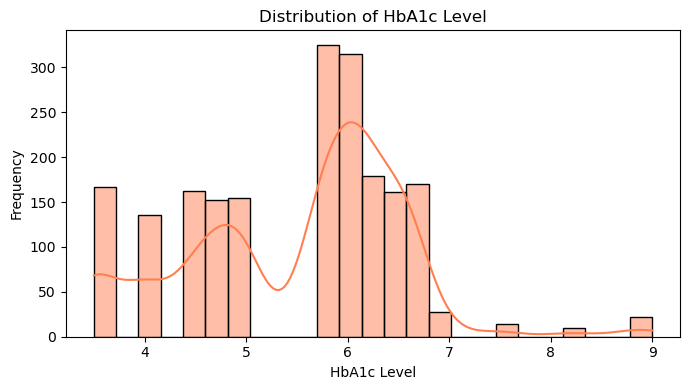

In [13]:
# HbA1c distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["HbA1c_level"], bins=25, kde=True, color="coral")
plt.title("Distribution of HbA1c Level")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The HbA1c distribution shows how the measured HbA1c values vary among the patients. The spread of this feature is useful when examining its relationship with the diabetes target.

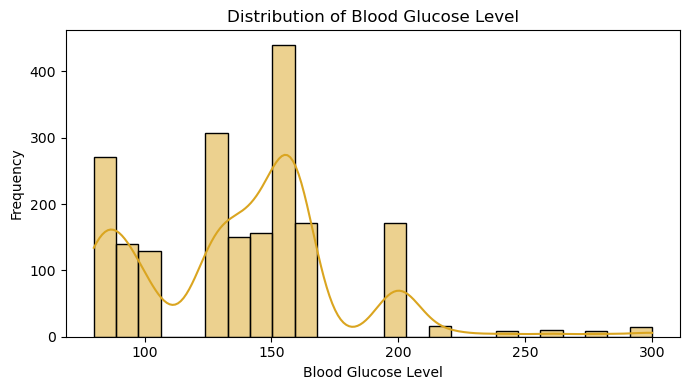

In [14]:
# Blood glucose distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["blood_glucose_level"], bins=25, kde=True, color="goldenrod")
plt.title("Distribution of Blood Glucose Level")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The blood glucose distribution shows the range and frequency of glucose measurements. This feature is particularly relevant to the classification problem because it can provide useful information for distinguishing the diabetes classes.

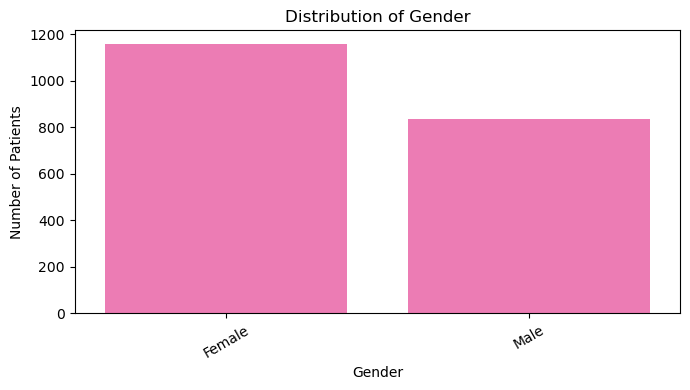

In [15]:
# Gender distribution

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="gender", color="hotpink")
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight

The gender distribution shows how the patient records are divided among the available gender categories. This helps identify whether the dataset contains a similar number of records across the categories or whether one category is more common.

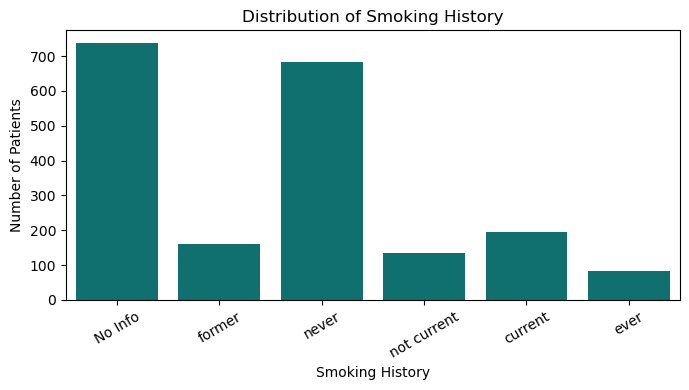

In [16]:
# Smoking history distribution

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="smoking_history", color="teal")
plt.title("Distribution of Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight

The smoking-history distribution shows the number of patients in each smoking category. This gives an overview of the categorical feature before it is encoded for model training.

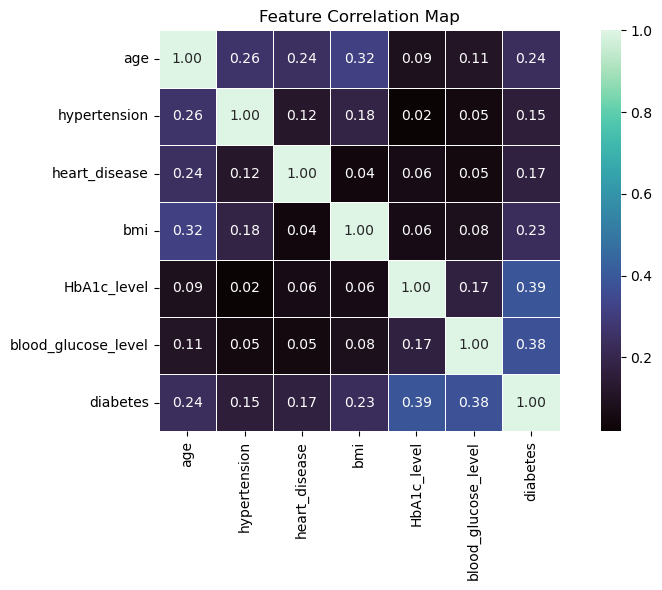

In [17]:
# Correlation heatmap
corr = df[num_cols + ["diabetes"]].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="mako",
    linewidths=0.6,
    square=True
)
plt.title("Feature Correlation Map")
plt.tight_layout()
plt.show()

### Insight

The correlation heatmap shows the linear relationships among the numerical features and the diabetes target. It helps identify features that have stronger or weaker linear relationships with the target and also shows relationships between the input features themselves.

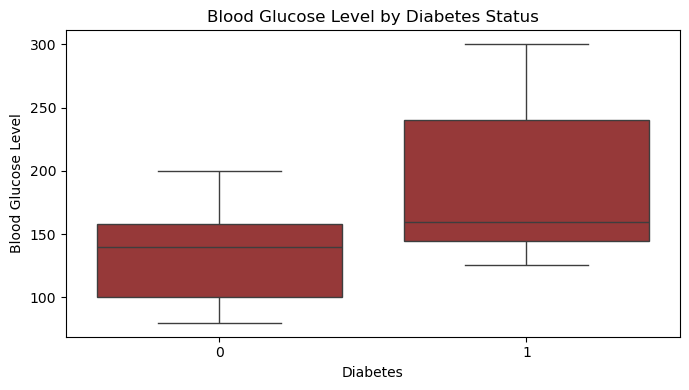

In [18]:
# Blood glucose level by diabetes status

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="diabetes",
    y="blood_glucose_level",
    color="brown"
)
plt.title("Blood Glucose Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Blood Glucose Level")
plt.tight_layout()
plt.show()

### Insight

The boxplot compares blood glucose levels between the two diabetes classes. A difference in the central values and spread between the groups suggests that blood glucose level may provide useful information for distinguishing the target classes.

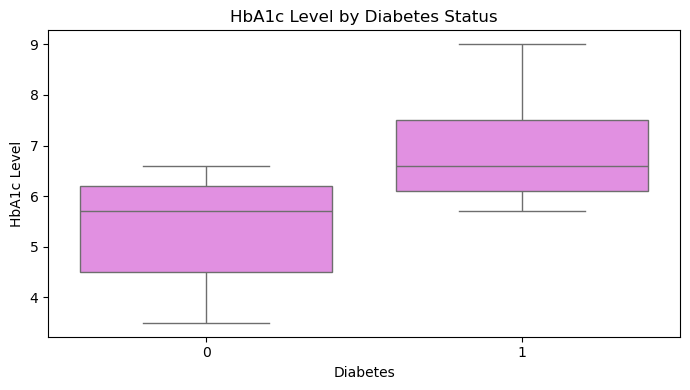

In [19]:
# HbA1c level by diabetes status

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="diabetes",
    y="HbA1c_level",
    color="violet"
)
plt.title("HbA1c Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level")
plt.tight_layout()
plt.show()

### Insight

The HbA1c boxplot compares the distribution of HbA1c values between patients with and without diabetes. Differences in the distributions indicate that this feature may help the KNN classifier separate the two classes.

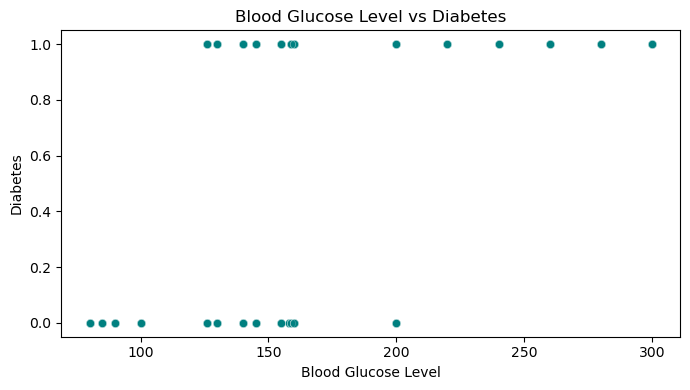

In [20]:
# Scatter plot: Blood glucose vs diabetes

plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="blood_glucose_level",
    y="diabetes",
    alpha=0.45,
    color="teal"
)
plt.title("Blood Glucose Level vs Diabetes")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()

### Insight

The scatter plot shows how the diabetes labels are distributed across blood glucose levels. The visible distribution of points across the two classes gives an indication of how useful blood glucose level may be for distinguishing diabetes status.

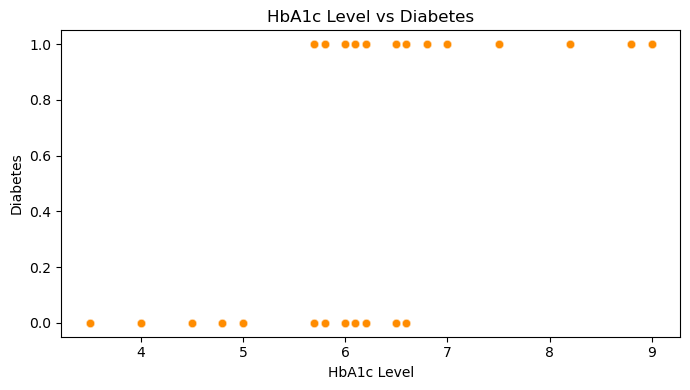

In [21]:
# Scatter plot: HbA1c vs diabetes

plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="HbA1c_level",
    y="diabetes",
    alpha=0.45,
    color="darkorange"
)
plt.title("HbA1c Level vs Diabetes")
plt.xlabel("HbA1c Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()

### Insight

The scatter plot shows the distribution of diabetes labels across different HbA1c levels. The pattern of the points provides a visual indication of whether HbA1c level can help separate the two target classes.

In [22]:
# Check and treat outliers using the IQR method

outlier_cols = [
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers Found": count
    })
    df[col] = df[col].clip(lower=lower, upper=upper)

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Feature,Lower Bound,Upper Bound,Outliers Found
0,bmi,14.66375,38.61375,143
1,HbA1c_level,2.70000,8.30000,22
2,blood_glucose_level,11.50000,247.50000,33


## Feature Engineering

An interaction feature is created using blood glucose level and HbA1c level.

These two variables are directly relevant to the diabetes prediction problem. Combining them creates an additional feature that represents their joint effect and gives the KNN model another input that may help separate the two classes.

In [35]:
# Create an engineered feature

df["glucose_hba1c_interaction"] = (
    df["blood_glucose_level"] * df["HbA1c_level"]
)

print("Engineered feature created: glucose_hba1c_interaction")
df[["blood_glucose_level","HbA1c_level","glucose_hba1c_interaction"]].head()

Engineered feature created: glucose_hba1c_interaction


,blood_glucose_level,HbA1c_level,glucose_hba1c_interaction
0,126.0,5.8,730.8
1,145.0,5.0,725.0
2,200.0,3.5,700.0
3,126.0,6.1,768.6
4,200.0,6.2,1240.0


In [24]:
# Separating features and target

x = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (1996, 9)
Target shape: (1996,)


In [25]:
# Stratified train-test split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data: (1596, 9)
Testing data: (400, 9)

Training target distribution:
diabetes
0    0.917
1    0.083
Name: proportion, dtype: float64

Testing target distribution:
diabetes
0    0.918
1    0.082
Name: proportion, dtype: float64


In [26]:
# Preprocessing method

num_features = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "glucose_hba1c_interaction"
]

cat_features = [
    "gender",
    "smoking_history"
]

prep = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features
        )
    ]
)

In [27]:
# Building the KNN model

knn_model = Pipeline(
    steps=[
        ("preprocessing", prep),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=5,
                weights="uniform",
                metric="minkowski"
            )
        )
    ]
)

In [28]:
# Training the KNN model

knn_model.fit(x_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [29]:
# Making predictions

knn_pred = knn_model.predict(x_test)
knn_prob = knn_model.predict_proba(x_test)[:, 1]

print("First 10 KNN predictions:")
print(knn_pred[:10])

First 10 KNN predictions:
[0 0 0 0 0 0 0 0 0 0]


In [30]:
# Calculating KNN evaluation metrics

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, zero_division=0)
knn_recall = recall_score(y_test, knn_pred, zero_division=0)
knn_f1 = f1_score(y_test, knn_pred, average="weighted")
knn_auc = roc_auc_score(y_test, knn_prob)

print("KNN Classification Results")
print("---------------------------")
print("Accuracy    :", knn_accuracy)
print("Precision   :", knn_precision)
print("Recall      :", knn_recall)
print("Weighted F1 :", knn_f1)
print("ROC-AUC     :", knn_auc)

KNN Classification Results
---------------------------
Accuracy    : 0.955
Precision   : 0.8947368421052632
Recall      : 0.5151515151515151
Weighted F1 : 0.9493634306869602
ROC-AUC     : 0.8680951201387168


In [31]:
# Classification report for KNN

print(classification_report(y_test,knn_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       367
           1       0.89      0.52      0.65        33

    accuracy                           0.95       400
   macro avg       0.93      0.75      0.81       400
weighted avg       0.95      0.95      0.95       400



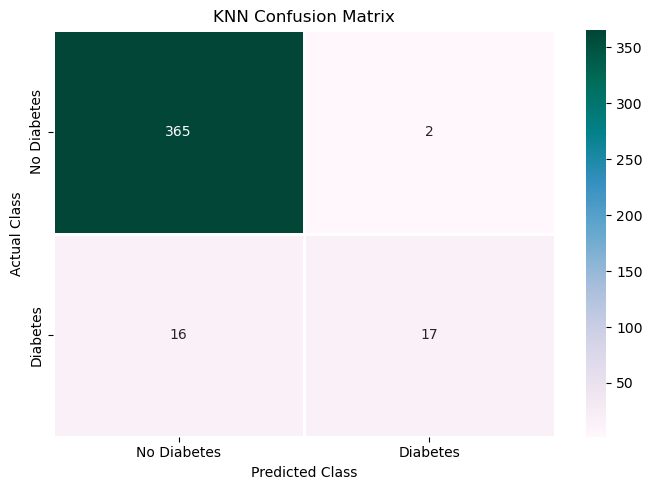

In [32]:
# KNN confusion matrix

cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    linewidths=1,
    linecolor="white",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

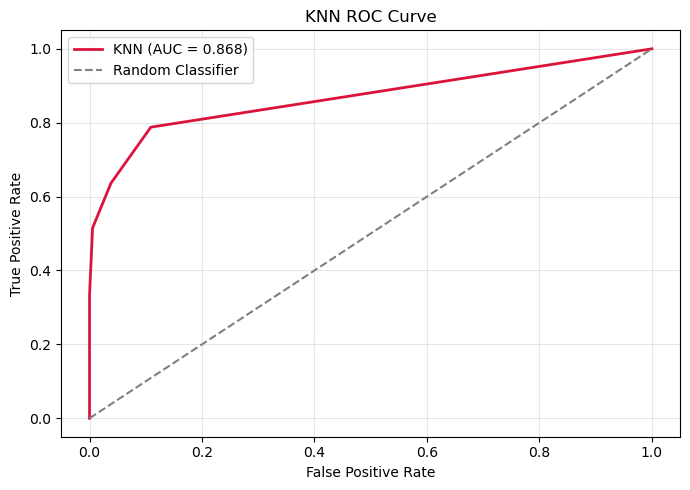

In [33]:
# ROC Curve for KNN

fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test,knn_prob)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr_knn,
    tpr_knn,
    color="crimson",
    linewidth=2,
    label=f"KNN (AUC = {knn_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Save results for the final 5-model classification comparison table

import os
os.makedirs("../results", exist_ok=True)
results_path = "../results/classification_results.csv"

row = pd.DataFrame([{
    "Model": "K-Nearest Neighbors",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "Weighted F1": knn_f1,
    "ROC-AUC": knn_auc
}])

if os.path.exists(results_path):
    saved = pd.read_csv(results_path)
    saved = saved[saved["Model"] != "K-Nearest Neighbors"]
    row = pd.concat([saved, row], ignore_index=True)

row.to_csv(results_path, index=False)

os.makedirs("../results/predictions", exist_ok=True)
pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": knn_pred,
    "y_prob": knn_prob
}).to_csv(
    "../results/predictions/K-Nearest Neighbors.csv",
    index=False
)
row.sort_values(
    "Weighted F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,K-Nearest Neighbors,0.955,0.894737,0.515152,0.949363,0.868095
1,Logistic Regression,0.945,0.789474,0.454545,0.938111,0.943110
